In [ ]:
!pip install copernicusmarine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.0/119.0 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 8.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, 

In [ ]:
import copernicusmarine

copernicusmarine.subset(
  dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
  variables=["thetao"],
  minimum_longitude = 124.0,
  maximum_longitude = 128.0,
  minimum_latitude = 28.0,
  maximum_latitude = 33.0,
  start_datetime="2012-08-19T00:00:00",
  end_datetime="2026-04-28T00:00:00",
  minimum_depth=0.49402499198913574,
  maximum_depth=0.49402499198913574,
)

INFO - 2026-07-23T23:22:42Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: sherxonazimov94@gmail.com
Copernicus Marine password: ··········


INFO - 2026-07-23T23:23:14Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-07-23T23:23:14Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


  0%|          | [00:00<?]

INFO - 2026-07-23T23:23:22Z - Total size of the download: 28.54 MB.
INFO:copernicusmarine:Total size of the download: 28.54 MB.


ResponseSubset(file_path=PosixPath('cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao_124.00E-128.00E_28.00N-33.00N_0.49m_2012-08-19-2026-04-28.nc'), output_directory=PosixPath('.'), filename='cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao_124.00E-128.00E_28.00N-33.00N_0.49m_2012-08-19-2026-04-28.nc', file_size=28.5396965648855, data_transfer_size=390.4019541984733, variables=['thetao'], coordinates_extent=[GeographicalExtent(minimum=124.0, maximum=128.0, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=28.0, maximum=33.0, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2012-08-19T00:00:00+00:00', maximum='2026-04-28T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=0.49402499198913574, maximum=0.49402499198913574, unit='m', coordinate_id='depth')], status='000', message='The request was successful.', file_status='DOWNLOADED', file_names=None)

In [ ]:
import xarray as xr
ds = xr.open_dataset("cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao_124.00E-128.00E_28.00N-33.00N_0.49m_2012-08-19-2026-04-28.nc")
print(ds)

<xarray.Dataset> Size: 120MB
Dimensions:    (time: 5001, depth: 1, latitude: 61, longitude: 49)
Coordinates:
  * time       (time) datetime64[ns] 40kB 2012-08-19 2012-08-20 ... 2026-04-28
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 244B 28.0 28.08 28.17 ... 32.83 32.92 33.0
  * longitude  (longitude) float32 196B 124.0 124.1 124.2 ... 127.8 127.9 128.0
Data variables:
    thetao     (time, depth, latitude, longitude) float64 120MB ...
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                    

In [ ]:
import numpy as np

# 1. Extract 3D numpy array, dropping depth: shape (T, Lat, Lon) -> (5001, 49, 27)
sst_np = ds["thetao"].squeeze().values

# 2. Extract 2D boolean mask for valid ocean points: shape (49, 27)
ocean_mask = ~np.isnan(sst_np[0])

# 3. Filter out land (NaN) cells: shape (T, ocean_features) -> (5001, 1293)
X_nvar = sst_np[:, ocean_mask]

print("NVAR input shape before transpose:", X_nvar.shape)  # (5001, 1293)

# 4. Transpose to (features, time) and save: shape (1293, 5001)
np.save("east_china_sea_sst.npy", X_nvar.T)

print(
    "Saved file shape (features, T):", np.load("east_china_sea_sst.npy").shape
)

NVAR input shape before transpose: (5001, 2989)
Saved file shape (features, T): (2989, 5001)


In [ ]:
import numpy as np

# Extract 2D array for a single timestamp
sst_2d = ds["thetao"].isel(time=0, depth=0).values

# Water = True, Land = False
ocean_mask = ~np.isnan(sst_2d)

# 1. Check if any land (False) exists
has_land = False in ocean_mask  # Returns True

# 2. Count total land points (False entries)
num_land_points = np.sum(~ocean_mask)
print(f"Number of land cells (False): {num_land_points}")

Number of land cells (False): 0


In [ ]:
sst = ds['thetao']
print(sst.shape)  # (time, depth, lat, lon)

(5001, 1, 61, 49)


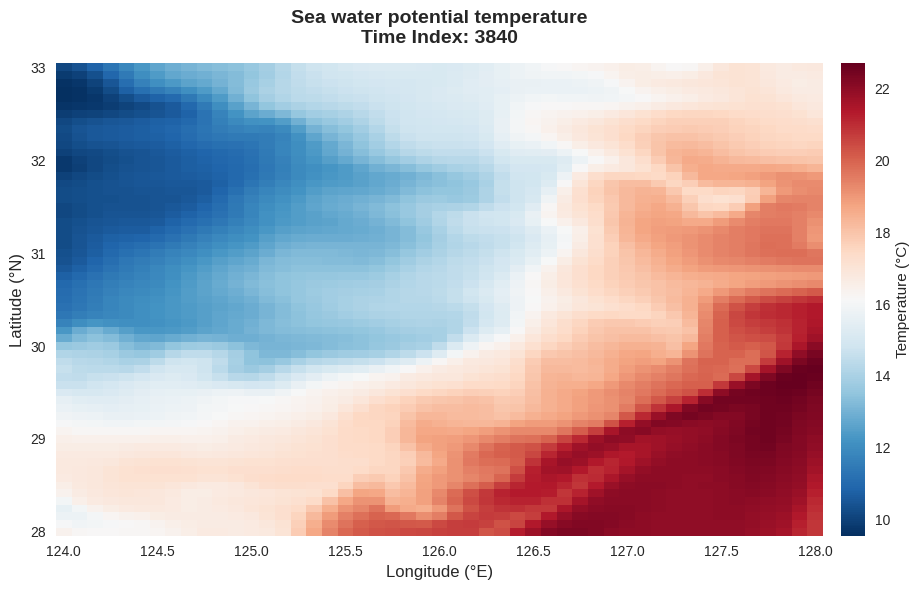

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set a professional style for the plot
plt.style.use('seaborn-v0_8')  # Use a clean, professional matplotlib style

# Randomly select a time index
random_time_index = np.random.randint(0, sst.shape[0])

# Extract sea surface salinity at the selected time index (depth = 0)
sal_slice = sst.isel(time=random_time_index, depth=0)

# Create a figure with a professional size and resolution
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# Plot the salinity slice with a colorbar
plot = sal_slice.plot(
    cmap='RdBu_r',  # Use a diverging colormap for better contrast
    ax=ax,
    cbar_kwargs={
        'label': 'Temperature (°C)',  # Professional label for colorbar
        'pad': 0.02,  # Adjust colorbar position
    }
)

# Customize the plot title and labels
ax.set_title(
    f'Sea water potential temperature\nTime Index: {random_time_index}',
    fontsize=14,
    pad=15,
    weight='bold'
)
ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontsize=12)

# Improve tick label formatting
ax.tick_params(axis='both', which='major', labelsize=10)

# Ensure the plot layout is tight to avoid clipping
plt.tight_layout()

# Save the plot as a high-resolution PNG
plt.savefig('Sea_water_potential_temperature.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

# Close the figure to free memory
plt.close(fig)